In [1]:
title = "# Probabilities: Exercise Solutions"
import bayesian_stats_course_tools
bayesian_stats_course_tools.misc.display_markdown_and_setup_tex(title)

import itertools
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.style
matplotlib.style.use("bayesian_stats_course_tools.light")
rng = np.random.default_rng(0)

# Probabilities: Exercise Solutions

<!-- Define LaTeX macros -->
$\def\E{\operatorname{E}}$
$\def\Var{\operatorname{Var}}$
$\def\Cov{\operatorname{Cov}}$
$\def\dd{\mathrm{d}}$
$\def\ee{\mathrm{e}}$
$\def\Norm{\mathcal{N}}$
$\def\Uniform{\mathcal{U}}$
$\def\GP{\mathcal{GP}}$

<!-- MathJax needs them to be defined again for the non-inline environment -->
$$\def\E{\operatorname{E}}$$
$$\def\Var{\operatorname{Var}}$$
$$\def\Cov{\operatorname{Cov}}$$
$$\def\dd{\mathrm{d}}$$
$$\def\ee{\mathrm{e}}$$
$$\def\Norm{\mathcal{N}}$$
$$\def\Uniform{\mathcal{U}}$$
$$\def\GP{\mathcal{GP}}$$

---
## Exercise 0: Warm-up

### 1. Sum of two dice equals 7

Enumerate the 36 equally-likely $(d_1, d_2)$ outcomes and count how many sum to 7.

In [2]:
omega = list(itertools.product(range(1, 7), range(1, 7)))

event_sum_7 = {(d1, d2) for d1, d2 in omega if d1 + d2 == 7}
pr_sum_7 = len(event_sum_7) / len(omega)
print(f"P(sum = 7) = {len(event_sum_7)}/{len(omega)} = {pr_sum_7:.4f}")

P(sum = 7) = 6/36 = 0.1667


### 2. Is "sum = 7" independent of "at least one die is a 4"?

$A$ and $B$ are independent iff $P(A \mid B) = P(A)$.

In [3]:
event_A = event_sum_7
event_B = {(d1, d2) for d1, d2 in omega if d1 == 4 or d2 == 4}

pr_A = len(event_A) / len(omega)
pr_A_given_B = len(event_A & event_B) / len(event_B)

print(f"P(A) = {pr_A:.4f}")
print(f"P(A | B) = {pr_A_given_B:.4f}")
print("Independent?", np.isclose(pr_A, pr_A_given_B))

P(A) = 0.1667
P(A | B) = 0.1818
Independent? False


$P(A) = 6/36 = 1/6$, but $P(A \mid B) = 2/11$ (of the 11 outcomes with at least one 4, only $(4,3)$ and $(3,4)$ sum to 7). Since $2/11 \ne 1/6$, **$A$ and $B$ are not independent**: knowing a 4 was rolled changes the odds of the sum being 7.

### 3. Bayes' theorem: testing for a rare disease

$$P(D \mid {+}) = \frac{P(+ \mid D)\,P(D)}{P(+ \mid D)\,P(D) + P(+ \mid D^c)\,P(D^c)}$$

with $P(D) = 0.001$, $P(+\mid D) = 0.99$, $P(+\mid D^c) = 0.02$.

In [4]:
pr_D = 0.001
pr_pos_given_D = 0.99
pr_pos_given_not_D = 0.02

numerator = pr_pos_given_D * pr_D
denominator = numerator + pr_pos_given_not_D * (1 - pr_D)
pr_D_given_pos = numerator / denominator

print(f"P(disease | positive test) = {pr_D_given_pos:.3f}")

P(disease | positive test) = 0.047


Only about **4.7%** of people who test positive actually have the disease. Because the disease is rare, the much larger healthy population produces more false positives (2% of ~99.9% of everyone) than the small diseased population produces true positives (99% of ~0.1% of everyone).

---
## Exercise 1: The birthday problem

### Derivation

$P(B_n) = 1 - P(B_n^c)$, where $B_n^c$ is the event that, out of $n$ people, no one shares a birthday.

Let $d_i$ be the birthday of person $i$. Then

$$P(B_n^c) = P\big(d_2 \notin \{d_1\},\, d_3 \notin \{d_1, d_2\},\, \dots,\, d_n \notin \{d_1, \dots, d_{n-1}\}\big)$$

Since birthdays are independent,

$$P(B_n^c) = P(d_2 \notin \{d_1\}) \cdot P(d_3 \notin \{d_1, d_2\}) \cdots P(d_n \notin \{d_1, \dots, d_{n-1}\})$$

with $P(d_i \notin \{d_1, \dots, d_{i-1}\}) = \dfrac{365 - (i - 1)}{365}$. Multiplying these together,

$$P(B_n^c) = \prod_{i=1}^{n} \frac{365 - (i-1)}{365} = \frac{365!}{(365-n)!\, 365^n}$$

and so

$$P(B_n) = 1 - \frac{365!}{(365-n)!\, 365^n}$$

### Implementation

Forming $365!$ directly with `math.factorial` is fine numerically up to a point, but it's cleaner (and avoids ever forming an astronomically large intermediate integer) to compute the product term by term with `numpy`. We show both, plus Stirling's approximation, to confirm they agree.

In [5]:
def prob_no_shared_birthday_product(n, days=365):
    """P(B_n^c) via a direct running product -- the recommended approach."""
    return np.prod([(days - i) / days for i in range(n)])


def prob_no_shared_birthday_factorial(n, days=365):
    """P(B_n^c) via the closed-form factorial expression."""
    return math.factorial(days) / math.factorial(days - n) / days**n


def log_factorial_stirling(n):
    """Stirling's approximation to log(n!), to second order."""
    return n * np.log(n) - n + 0.5 * np.log(2 * np.pi * n) + 1 / (12 * n)


def prob_no_shared_birthday_stirling(n, days=365):
    log_p = log_factorial_stirling(days) - log_factorial_stirling(days - n) - n * np.log(days)
    return np.exp(log_p)


def prob_shared_birthday(n, days=365, method="product"):
    """P(B_n): the probability that at least two of n people share a birthday."""
    implementations = {
        "product": prob_no_shared_birthday_product,
        "factorial": prob_no_shared_birthday_factorial,
        "stirling": prob_no_shared_birthday_stirling,
    }
    return 1 - implementations[method](n, days)

In [6]:
for n in (17, 23):
    print(f"n = {n}:")
    for method in ("product", "factorial", "stirling"):
        print(f"  P(B_{n}) [{method:>9s}] = {prob_shared_birthday(n, method=method):.4f}")

n = 17:
  P(B_17) [  product] = 0.3150
  P(B_17) [factorial] = 0.3150
  P(B_17) [ stirling] = 0.3150
n = 23:
  P(B_23) [  product] = 0.5073
  P(B_23) [factorial] = 0.5073
  P(B_23) [ stirling] = 0.5073


All three methods agree. With $n=23$ people the probability of a shared birthday is just over 50% -- the group only needs to be pretty small before a coincidence becomes the *likely* outcome, which is why this problem is famous for being counter-intuitive.

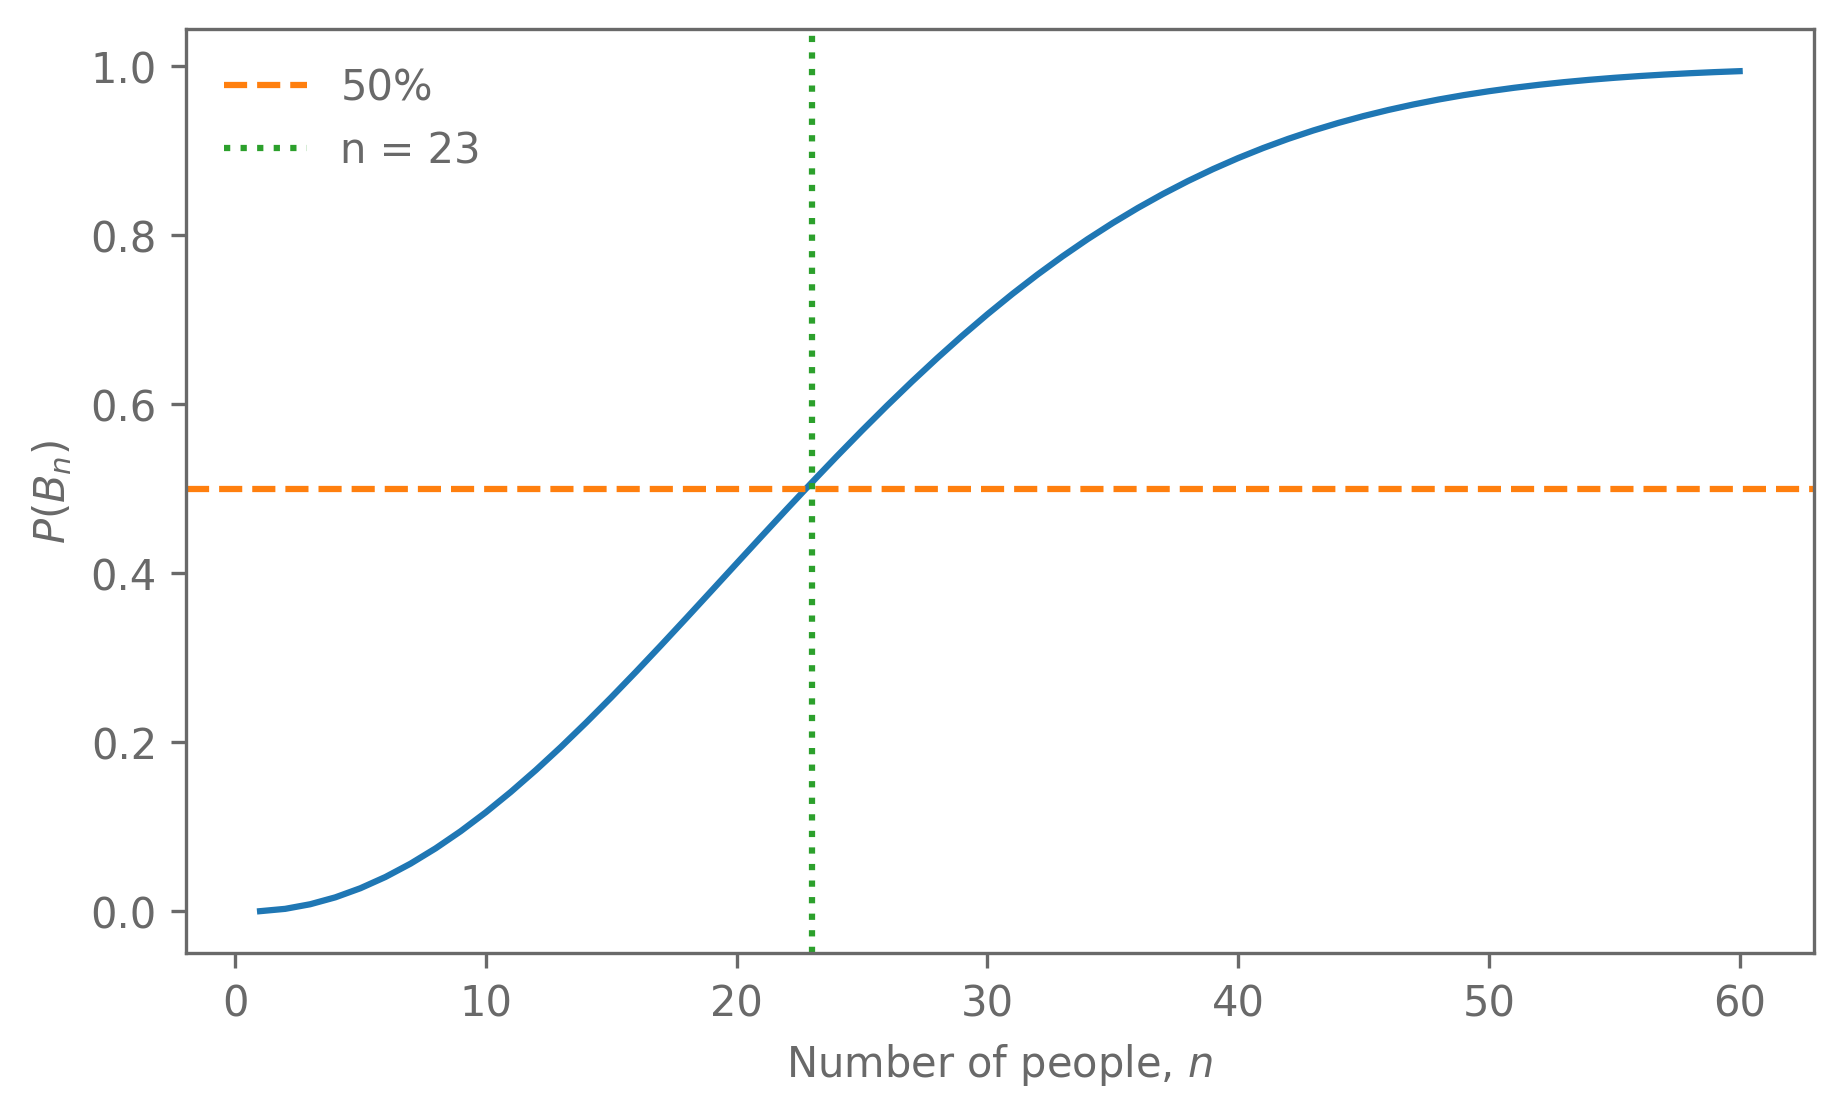

In [7]:
n_values = np.arange(1, 61)
probabilities = [prob_shared_birthday(n) for n in n_values]

plt.plot(n_values, probabilities)
plt.axhline(0.5, color="C1", ls="--", label="50%")
plt.axvline(23, color="C2", ls=":", label="n = 23")
plt.xlabel("Number of people, $n$")
plt.ylabel(r"$P(B_n)$")
plt.legend()
plt.show()

### Bonus: a different number of days in the year

The derivation above never used the number 365 except as a parameter, so `prob_shared_birthday(n, days=D)` already generalises. The "50% group size" grows roughly as $\sqrt{D}$ (this can be seen by approximating $P(B_n^c) \approx \exp(-n^2/2D)$ for $n \ll D$, and solving $\exp(-n^2/2D) = 1/2$).

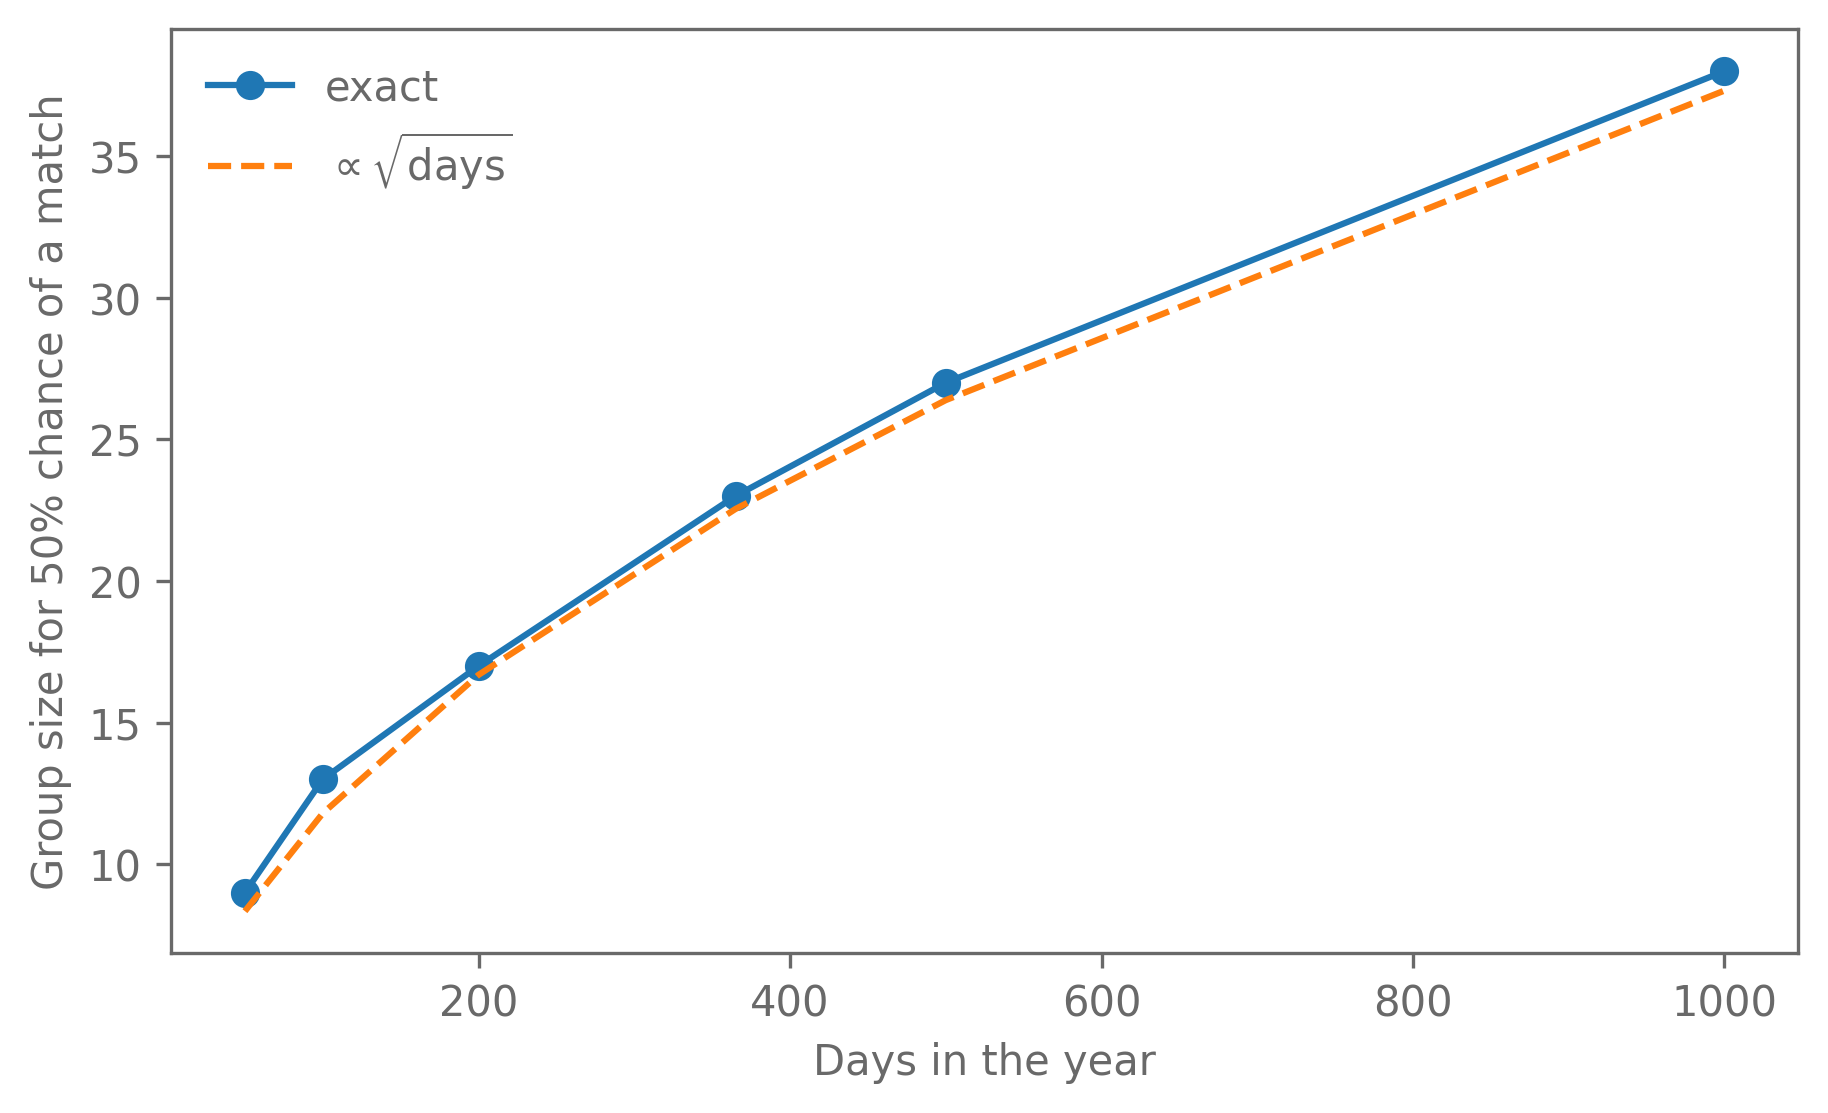

In [8]:
def fifty_percent_group_size(days):
    """Smallest n for which P(B_n) >= 0.5, found by direct search."""
    n = 1
    while prob_shared_birthday(n, days=days) < 0.5:
        n += 1
    return n


day_counts = np.array([50, 100, 200, 365, 500, 1000])
fifty_percent_ns = [fifty_percent_group_size(d) for d in day_counts]

plt.plot(day_counts, fifty_percent_ns, "o-", label="exact")
plt.plot(day_counts, 1.18 * np.sqrt(day_counts), "--", label=r"$\propto \sqrt{\mathrm{days}}$")
plt.xlabel("Days in the year")
plt.ylabel("Group size for 50% chance of a match")
plt.legend()
plt.show()

---
## Exercise 2: The Monty Hall problem

Let $M$ denote the hypothesis stated in the exercise -- the rules of the game (uniformly random car placement; the host always opens a remaining door to reveal a goat). Every probability below is implicitly conditioned on $M$; we write it explicitly since the answer follows from these specific rules.

### A. Simulation

In [9]:
def play_monty_hall(rng):
    """Play one round; return whether sticking wins and whether switching wins."""
    doors = (0, 1, 2)
    car_door = rng.integers(3)
    chosen_door = rng.integers(3)

    # host opens a door that is neither the chosen door nor the car door
    openable = [d for d in doors if d != chosen_door and d != car_door]
    host_opens = rng.choice(openable)

    switch_door = next(d for d in doors if d not in (chosen_door, host_opens))

    stick_wins = chosen_door == car_door
    switch_wins = switch_door == car_door
    return stick_wins, switch_wins


n_rounds = 100_000
results = np.array([play_monty_hall(rng) for _ in range(n_rounds)])
pr_win_stick = results[:, 0].mean()
pr_win_switch = results[:, 1].mean()

print(f"P(win | stick)   ~ {pr_win_stick:.4f}   (exact: 1/3 = {1/3:.4f})")
print(f"P(win | switch)  ~ {pr_win_switch:.4f}   (exact: 2/3 = {2/3:.4f})")

P(win | stick)   ~ 0.3333   (exact: 1/3 = 0.3333)
P(win | switch)  ~ 0.6666   (exact: 2/3 = 0.6667)


### B. Analytic derivation

By Bayes' theorem,

$$P(C_1 \mid H_3, M) = \frac{P(H_3 \mid C_1, M)\,P(C_1 \mid M)}{P(H_3 \mid M)}$$

**Numerator ingredients:**
- $P(H_3 \mid C_1, M) = \tfrac{1}{2}$: if the car is behind door 1 (the door the contestant chose), doors 2 and 3 both have goats, and the host picks between them at random.
- $P(C_1 \mid M) = \tfrac{1}{3}$: the prior probability the car is behind any given door.

**Denominator**, expanded with the law of total probability over the three possible car locations:

$$P(H_3 \mid M) = P(H_3 \mid C_1, M)P(C_1 \mid M) + P(H_3 \mid C_2, M)P(C_2 \mid M) + P(H_3 \mid C_3, M)P(C_3 \mid M)$$

- $P(H_3 \mid C_2, M) = 1$: the contestant chose door 1 and the car is behind door 2, so the host's *only* choice that reveals a goat is door 3.
- $P(H_3 \mid C_3, M) = 0$: the host never opens the door hiding the car.

Putting it together:

$$P(C_1 \mid H_3, M) = \frac{\tfrac12 \cdot \tfrac13}{\tfrac12\cdot\tfrac13 + 1\cdot\tfrac13 + 0\cdot\tfrac13} = \frac{1}{3}$$

and since $C_1$ and $C_2$ are the only two doors still in play, $P(C_2 \mid H_3, M) = 1 - P(C_1 \mid H_3, M) = \tfrac{2}{3}$ -- **switching doubles your chances of winning**, matching the simulation above.

**Shortcut via posterior odds.** The denominator $P(H_3 \mid M)$ is shared by both posteriors, so it cancels in the ratio:

$$\frac{P(C_2 \mid H_3, M)}{P(C_1 \mid H_3, M)} = \frac{P(H_3 \mid C_2, M)}{P(H_3 \mid C_1, M)}\cdot\frac{P(C_2 \mid M)}{P(C_1 \mid M)} = \frac{1}{1/2}\cdot 1 = 2$$

This shows directly that switching is twice as good as sticking, without ever computing $P(H_3 \mid M)$: the prior odds ($=1$, the car is equally likely behind either remaining door) are updated by the likelihood ratio ($=2$, since the host was forced to open door 3 if the car was behind door 2, but only did so with 50% probability if the car was behind door 1).

In [10]:
pr_C1_given_H3 = (1 / 2 * 1 / 3) / (1 / 2 * 1 / 3 + 1 * 1 / 3 + 0 * 1 / 3)
pr_C2_given_H3 = 1 - pr_C1_given_H3

print(f"P(C1 | H3) analytic  = {pr_C1_given_H3:.4f}   vs. simulated P(win | stick)  = {pr_win_stick:.4f}")
print(f"P(C2 | H3) analytic  = {pr_C2_given_H3:.4f}   vs. simulated P(win | switch) = {pr_win_switch:.4f}")

P(C1 | H3) analytic  = 0.3333   vs. simulated P(win | stick)  = 0.3333
P(C2 | H3) analytic  = 0.6667   vs. simulated P(win | switch) = 0.6666


### Bonus: $N$ doors

Call the generalised rules $M_N$: with $N$ doors, the host opens $N - 2$ of the remaining $N - 1$ doors (all goats), leaving one closed door besides the contestant's original choice. By the same reasoning:

- $P(\text{win} \mid \text{stick}, M_N) = \dfrac{1}{N}$ -- sticking never benefits from the host's information.
- $P(\text{win} \mid \text{switch}, M_N) = 1 - \dfrac{1}{N} = \dfrac{N-1}{N}$ -- all the probability mass that was *not* on the original door collapses onto the single remaining door once the host reveals every other goat.

As $N$ grows, switching approaches a near-certain win. We check this by extending the simulation.

In [11]:
def play_monty_hall_n_doors(rng, n_doors):
    doors = np.arange(n_doors)
    car_door = rng.integers(n_doors)
    chosen_door = rng.integers(n_doors)

    # host opens every door except the contestant's choice and the car,
    # leaving exactly one other closed door
    openable = [d for d in doors if d not in (chosen_door, car_door)]
    doors_to_open = rng.choice(openable, size=n_doors - 2, replace=False)
    switch_door = next(d for d in doors if d not in (chosen_door, *doors_to_open))

    stick_wins = chosen_door == car_door
    switch_wins = switch_door == car_door
    return stick_wins, switch_wins


n_doors_values = [3, 4, 5, 10, 20]
n_rounds = 20_000
for n_doors in n_doors_values:
    results = np.array([play_monty_hall_n_doors(rng, n_doors) for _ in range(n_rounds)])
    pr_stick, pr_switch = results.mean(axis=0)
    print(f"N={n_doors:>2d}:  P(win|stick) ~ {pr_stick:.3f} (exact {1/n_doors:.3f})   "
          f"P(win|switch) ~ {pr_switch:.3f} (exact {(n_doors-1)/n_doors:.3f})")

N= 3:  P(win|stick) ~ 0.329 (exact 0.333)   P(win|switch) ~ 0.671 (exact 0.667)


N= 4:  P(win|stick) ~ 0.250 (exact 0.250)   P(win|switch) ~ 0.750 (exact 0.750)


N= 5:  P(win|stick) ~ 0.203 (exact 0.200)   P(win|switch) ~ 0.797 (exact 0.800)


N=10:  P(win|stick) ~ 0.099 (exact 0.100)   P(win|switch) ~ 0.901 (exact 0.900)


N=20:  P(win|stick) ~ 0.051 (exact 0.050)   P(win|switch) ~ 0.949 (exact 0.950)
